In [1]:
import builtins
# We define 'init' as a dummy function or object so the library doesn't crash
builtins.init = lambda: None 

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
import numpy as np
from tqdm import tqdm

# Now try the import
from PyTimeVar import GAS

# Suppress warnings
warnings.simplefilter('ignore', ValueWarning)
warnings.simplefilter('ignore', ConvergenceWarning)

## Data Sanity Check

<Axes: title={'center': 'CSAD_AVG'}, xlabel='Date'>

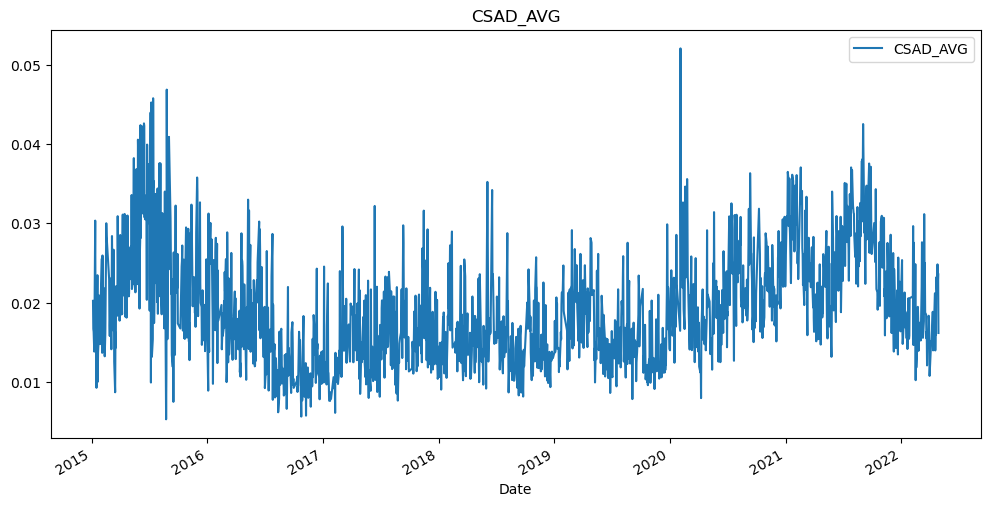

In [23]:
from PyTimeVar.datasets import herding

herd_data = herding.load(start_date='2015-01-05', end_date='2022-04-29')
vY = herd_data[['CSAD_AVG']].values
mX = np.ones_like(vY)

herd_data[['CSAD_AVG']].plot(figsize=(12, 6), title="CSAD_AVG")

In [24]:
from PyTimeVar import GAS

gasmodel = GAS(vY=vY, mX=mX, method='student')
tGAStrend, tGASparams = gasmodel.fit()

Time taken: 351.33 seconds


## Load Data

In [25]:
selected_data = pd.read_csv('etfs_macro_large.csv')

selected_data.head()

,date,SPY,XLI,XLE,XLK,XLV,XLU,XLF,XLY,XLP,...,DDURRG3M086SBEA,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST
0,2000-02-01,-0.050622,-0.085334,0.008042,-0.063456,-0.025616,-0.017928,-0.030032,-0.132669,0.008781,...,-0.002376,0.005015,-0.000585,-0.000680,0.002320,-0.002843,-0.7,0.006184,-0.003170,-0.007322
1,2000-03-01,-0.015791,-0.056752,-0.043256,0.099907,-0.067623,-0.129583,-0.113220,-0.057327,-0.124446,...,0.004724,0.005486,-0.001198,-0.000673,-0.000606,0.000704,-4.2,-0.029803,-0.001179,0.016590
2,2000-04-01,0.092426,0.130235,0.117210,0.080559,0.086132,0.103583,0.167561,0.132281,0.036913,...,-0.003455,-0.016761,-0.001331,0.001973,0.001705,0.002106,2.1,-0.000135,0.008686,-0.005609
3,2000-05-01,-0.035753,0.014343,-0.015037,-0.096342,-0.011786,0.063406,0.009613,-0.021042,0.051661,...,0.001610,0.002287,0.001466,-0.004625,-0.006921,-0.004928,1.5,0.024727,-0.000153,-0.001897
4,2000-06-01,-0.015848,-0.004228,0.111026,-0.109789,-0.027170,-0.002196,0.022076,-0.055492,0.068900,...,-0.003220,0.010881,0.000796,0.003291,0.001150,0.006313,-4.3,-0.006503,0.008705,0.001113


<Axes: >

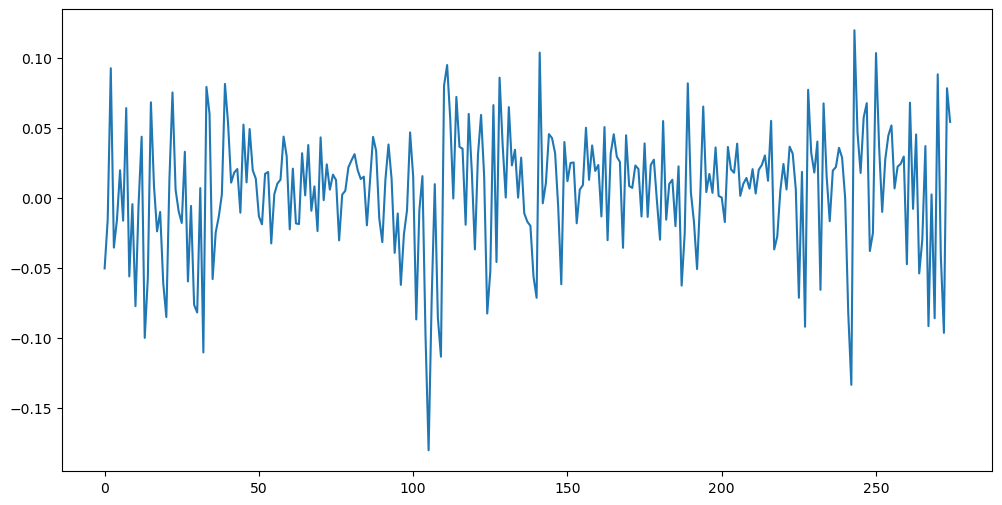

In [26]:
target = 'SPY'

selected_data[target].plot(figsize=(12, 6))

## Fit Model - Markov Switching dynamic Regression

In [27]:
# 1. Prepare data
vY = selected_data[target].values.flatten()
mX = np.ones((len(vY), 1))  # Intercept for the level

# 2. Initialize the t-GAS model
# The t-GAS model assumes u_t ~ t(0, sigma_u, nu) 
# The scale sigma_u is what captures the 'variance' over time
gas_model = GAS(vY=vY, mX=mX, method='student')

# 3. Fit the model
# This maximizes the log-likelihood to find static parameters [cite: 307]
tGAStrend, tGASparams = gas_model.fit()

# 4. Access the time-varying results
# gas_model.betas contains the estimated path of the coefficients [cite: 741]
# gas_model.params contains the static vector (nu, sigma_u, omega, B, A) [cite: 735]

Time taken: 190.55 seconds


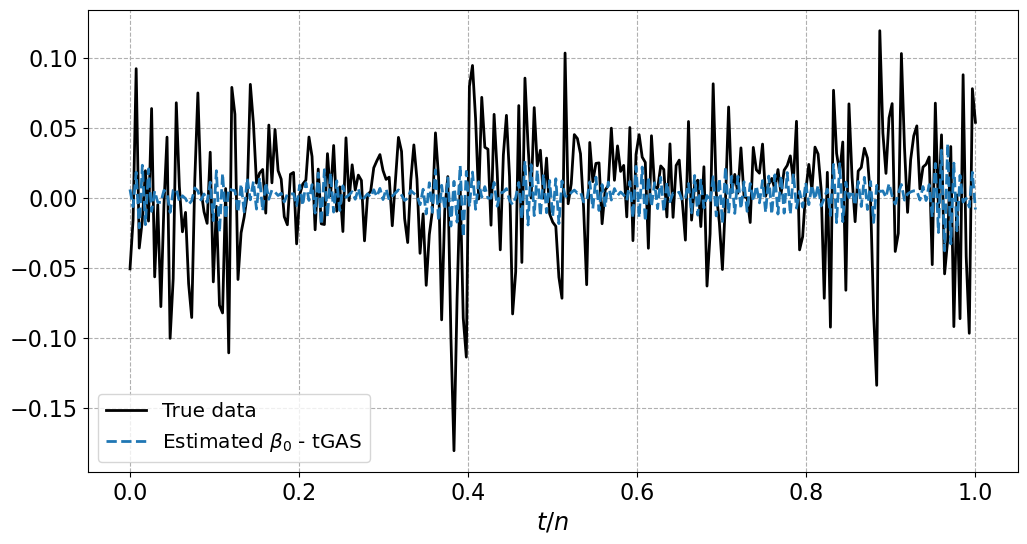

In [28]:
gas_model.plot()

<Axes: title={'center': 't-GAS Time-Varying Coefficients'}>

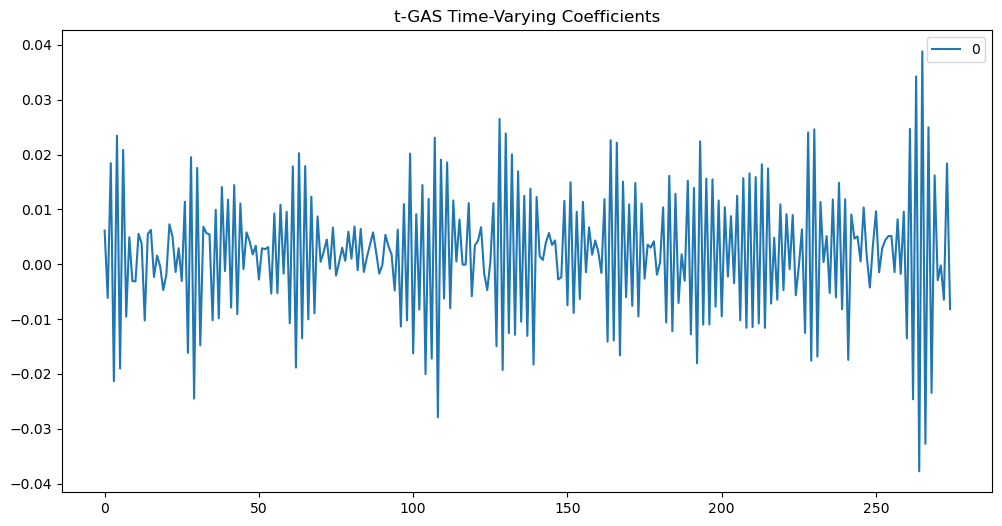

In [31]:
pd.DataFrame(tGAStrend).plot(figsize=(12, 6), title="t-GAS Time-Varying Coefficients")

## Walk-Forward Forecasting: First Step

In [ ]:
target = 'SPY'
fs_method = 'markov-switching-dyn-reg'
estimation_window = 12 * 7
fix_start = True
p = 1
max_p = 3

data = selected_data.copy()
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')

step = next(iter(range(0, len(data) - estimation_window, 1)))

if fix_start or (step == 0):
    start = 0
else:
    start += 1

train_df = data.iloc[start:(estimation_window + step), :]
test_df = data.iloc[start:(estimation_window + step + 1), :]

labelled_clusters = pd.DataFrame([{"fred": target, "cluster": 1, "description": target}])
selected_columns = list(train_df.drop([target], axis=1).columns)

train_df = train_df[[target] + selected_columns]

# zscore of train data
mean = train_df.mean()
std = train_df.std()

train_df = (train_df - mean) / std

# select optimal laga
if p == -1:
    var_select_model = VAR(train_df)
    selected_p = var_select_model.select_order(maxlags=max_p)
    selected_p = selected_p.selected_orders["aic"]
    if selected_p == 0:
        selected_p = 1
else:
    selected_p = min(p, max_p)

test_df = test_df[[target] + selected_columns].iloc[(estimation_window + step - selected_p):(estimation_window + step + 1), :]

# zscore of test data
test_df = (test_df - mean) / std

# subset data into train and test
Xt_train = train_df.drop([target], axis=1)
yt_train = train_df[[target]]

Xt_test = test_df.drop([target], axis=1)
yt_test = test_df[[target]]

# 1. Prepare Inputs
# vY must be a 1D array; mX must be a 2D matrix (even for a constant trend)
vY_train = yt_train.values.flatten()
mX_train = np.ones((len(vY_train), 1))  # Equivalent to trend='c'

methods = ['gaussian', 'student']
gas_models_summary = []

# 2. Iterative Fitting (Selection between N-GAS and t-GAS)
for method in methods:
    # Initialize the Score-driven model
    # niter=10 uses basin-hopping to avoid local optima
    mod_gas = GAS(vY=vY_train, mX=mX_train, method=method)
    
    # Fit returns (estimated_betas, static_parameters)
    # The likelihood is stored internally or calculated from params
    betas, params = mod_gas.fit()
    
    # Note: PyTimeVar doesn't expose AIC/BIC as direct attributes like statsmodels.
    # We record the method used and the resulting parameters.
    gas_models_summary.append({
        "method": method,
        "params": params,
        "betas": betas,
        "model_obj": mod_gas
    })

# 3. Final Model Selection
# Typically, t-GAS ('student') is selected for its robustness in financial series
selected_method = 'student' 
final_gas_model = GAS(vY=vY_train, mX=mX_train, method=selected_method)
final_res_betas, final_res_params = final_gas_model.fit()

# The estimated time-varying intercept (level) is in final_res_betas
# Shape is (n_features, n_observations)
current_level = final_res_betas[0, -1]

Time taken: 2.92 seconds
Time taken: 19.58 seconds
Time taken: 19.28 seconds


In [8]:
# 1. Identify how many features the model actually expects
# Based on your error, it's 84 total (Intercept + 83 features)
expected_feature_count = final_res_betas.shape[0] # This is 84
expected_exog_count = expected_feature_count - 1 # This is 83

# 2. Slice the columns to match the training state exactly
# We take only the first 83 columns from your list of 128
aligned_columns = selected_columns[:expected_exog_count]

# 3. Re-process mX_next with the aligned columns
test_sample = data.iloc[(estimation_window + step):(estimation_window + step + 1), :]
test_sample_norm = (test_sample - mean) / std

next_exog_values = test_sample_norm[aligned_columns].values.flatten()
mX_next = np.hstack([1, next_exog_values])

# 4. Extract betas and predict
next_step_betas = final_res_betas[:, -1]

# FINAL DIMENSION CHECK
print(f"Alinged mX_next size: {len(mX_next)}")
print(f"Model coefficients size: {len(next_step_betas)}")

y_hat_tp1 = np.dot(mX_next, next_step_betas)
print(f"One-step ahead GAS prediction: {y_hat_tp1:.6f}")

Alinged mX_next size: 84
Model coefficients size: 84
One-step ahead GAS prediction: -0.607671


## Walk-Forward Forecasting: Full Walk

In [11]:
?GAS

Init signature:
GAS(
    vY: numpy.ndarray,
    mX: numpy.ndarray,
    method: str = 'none',
    vgamma0: numpy.ndarray = None,
    bounds: list = None,
    options: dict = None,
    maxiter: int = 5,
)
Docstring:     
Class for performing score-driven (GAS) filtering.

Parameters
----------
vY : np.ndarray
    The dependent variable (response) array.
mX : np.ndarray
    The independent variable (predictor) matrix.
method : string
    Method to estimate GAS model.
vgamma0 : np.ndarray 
    Initial parameter vector.
bounds : list
    List to define parameter space.
options : dict
    Stopping criteria for optimization.
maxiter : int
    Maximum number of repitions of the optimization algorithm.
    If not provided, default is set to five repitions with different initial parameters.
    
Attributes
----------
vY : np.ndarray
    The dependent variable (response) array.
mX : np.ndarray
    The independent variable (predictor) matrix.
n : int
    The length of vY.
n_est : int
    The numbe

In [15]:
target = 'SPY'
fs_method = 'gas-gaussian'
estimation_window = 12 * 7
fix_start = True
p = 1
max_p = 3

subset_window = 12 * 8

data = selected_data.copy() # .iloc[:subset_window, :].copy()
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date').sort_index()

predictions = []

for step in tqdm(
    range(0, len(data) - estimation_window, 1),
    total=len(data) - estimation_window,
    desc=f"forecasting {fs_method}: {target}"
):
    if fix_start or (step == 0):
        start = 0
    else:
        start += 1

    train_end = estimation_window + step
    test_start = train_end
    test_end = train_end + 1

    train_df = data.iloc[start:train_end, :].copy()
    test_df = data.iloc[test_start:test_end, :].copy()

    if train_df.empty or test_df.empty:
        continue

    # --------------------------------------------------
    # SELECT FEATURES
    # --------------------------------------------------
    selected_columns = list(train_df.drop([target], axis=1).columns)
    train_df = train_df[[target] + selected_columns].copy()
    test_df = test_df[[target] + selected_columns].copy()

    # --------------------------------------------------
    # Z-SCORE NORMALIZATION
    # --------------------------------------------------
    mean = train_df.mean()
    std = train_df.std().replace(0, 1.0)

    train_df_z = (train_df - mean) / std
    test_df_z = (test_df - mean) / std

    # --------------------------------------------------
    # OPTIONAL LAG SELECTION
    # kept only for consistency with your original setup
    # if p != -1, this changes nothing
    # --------------------------------------------------
    if p == -1:
        try:
            var_select_model = VAR(train_df_z[[target] + selected_columns])
            selected_p = var_select_model.select_order(maxlags=max_p).selected_orders["aic"]
            if selected_p == 0 or selected_p is None:
                selected_p = 1
        except Exception:
            selected_p = 1
    else:
        selected_p = min(p, max_p)

    # NOTE:
    # In your current GAS setup, selected_p is not directly used unless
    # your selected_columns already contain lagged features.
    # So we keep selected_columns as-is, matching your single-window example.

    # --------------------------------------------------
    # PREPARE GAS INPUTS
    # --------------------------------------------------
    try:
        vY_train = train_df_z[target].values.flatten()
        mX_train = np.hstack([
            np.ones((len(vY_train), 1)),
            train_df_z[selected_columns].values
        ])

        # --------------------------------------------------
        # FIT STUDENT GAS
        # --------------------------------------------------
        gas_model = GAS(
            vY=vY_train,
            mX=mX_train,
            method='gaussian',
        )
        res_betas, res_params = gas_model.fit()

        # --------------------------------------------------
        # INFER ACTUAL FEATURE COUNT USED BY MODEL
        # --------------------------------------------------
        expected_feature_count = res_betas.shape[0]      # includes intercept
        expected_exog_count = expected_feature_count - 1

        aligned_columns = selected_columns[:expected_exog_count]

        # --------------------------------------------------
        # BUILD NEXT-STEP EXOG VECTOR
        # --------------------------------------------------
        test_sample_norm = test_df_z.copy()
        next_exog_values = test_sample_norm[aligned_columns].values.flatten()
        mX_next = np.hstack([1.0, next_exog_values])

        next_step_betas = res_betas[:, -1]

        # final dimension check
        if len(mX_next) != len(next_step_betas):
            min_dim = min(len(mX_next), len(next_step_betas))
            mX_next = mX_next[:min_dim]
            next_step_betas = next_step_betas[:min_dim]

        ypred_zscore = float(np.dot(mX_next, next_step_betas))

        # --------------------------------------------------
        # STORE PREDICTION
        # --------------------------------------------------
        yt_true_zscore = float(test_df_z[target].iloc[-1])
        ypred = float(ypred_zscore * std[target] + mean[target])
        yt_true = float(test_df[target].iloc[-1])

        pred = pd.DataFrame([{
            "date": test_df.index[-1],
            "prediction_zscore": ypred_zscore,
            "true_zscore": yt_true_zscore,
            "prediction": ypred,
            "true": yt_true,
            "selected_p": selected_p,
            "n_features_model": expected_feature_count,
            "n_exog_model": expected_exog_count,
        }])

        predictions.append(pred)

    except Exception as e:
        print(f"[step={step}] GAS fit/predict failed: {e}")
        continue

# --------------------------------------------------
# CONSOLIDATE RESULTS
# --------------------------------------------------
if len(predictions) == 0:
    predictions_df = pd.DataFrame(columns=[
        "prediction_zscore", "true_zscore",
        "prediction", "true",
        "selected_p", "n_features_model", "n_exog_model"
    ])
else:
    predictions_df = pd.concat(predictions, axis=0)

predictions_df['date'] = pd.to_datetime(predictions_df['date'])
predictions_df.set_index('date', inplace=True)

forecasting gas-gaussian: SPY:   0%|          | 0/191 [00:00<?, ?it/s]/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:262: RuntimeWarning: overflow encountered in square
  lhVal += ((yt - vbetaNow.T @ vxt) / dsigmau)**2
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
forecasting gas-gaussian: SPY:   1%|          | 1/191 [00:15<47:57, 15.14s/it]

Time taken: 13.72 seconds


/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:262: RuntimeWarning: overflow encountered in square
  lhVal += ((yt - vbetaNow.T @ vxt) / dsigmau)**2
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
forecasting gas-gaussian: SPY:   1%|          | 2/191 [00:32<51:21, 16.30s/it]

Time taken: 15.81 seconds


/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:262: RuntimeWarning: overflow encountered in square
  lhVal += ((yt - vbetaNow.T @ vxt) / dsigmau)**2
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
forecasting gas-gaussian: SPY:   2%|▏         | 3/191 [00:47<49:58, 15.95s/it]

...

Time taken: 29.12 seconds


/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:262: RuntimeWarning: overflow encountered in square
  lhVal += ((yt - vbetaNow.T @ vxt) / dsigmau)**2
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:262: RuntimeWarning: overflow encountered in matmul
  lhVal += ((yt - vbetaNow.T @ vxt) / dsigmau)**2
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:264: RuntimeWarning: overflow encountered in matmul
  mNablat = vxt * (yt - vbetaNow.T @ vxt)
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:262: RuntimeWarning: invalid value encountered in matmul
  lhVal += ((yt - vbetaNow.T @ vxt) / dsigmau)**2
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:264: RuntimeWarning: invalid value encountered in matmul
  mNablat = vxt * (yt - vbetaNow.T @ vxt)
forecasting gas-gaussian: SPY:  99%|█████████▉| 190/191 

Time taken: 29.46 seconds


/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:262: RuntimeWarning: overflow encountered in square
  lhVal += ((yt - vbetaNow.T @ vxt) / dsigmau)**2
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:265: RuntimeWarning: overflow encountered in multiply
  vbetaNow = vomega + mB * vbetaNow + mA * mNablat.squeeze()
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:262: RuntimeWarning: overflow encountered in matmul
  lhVal += ((yt - vbetaNow.T @ vxt) / dsigmau)**2
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:262: RuntimeWarning: invalid value encountered in matmul
  lhVal += ((yt - vbetaNow.T @ vxt) / dsigmau)**2
/home/danielco/miniconda3/envs/cml-fin/lib/python3.8/site-packages/PyTimeVar/gas/GAS.py:264: RuntimeWarning: overflow encountered in matmul
  mNablat = vxt * (yt - vbetaNow.T @ vxt)
/home/danielco/miniconda3/envs/cml-fin/l

Time taken: 79.13 seconds


In [16]:
predictions_df

,prediction_zscore,true_zscore,prediction,true,selected_p,n_features_model,n_exog_model
date,,,,,,,
2007-02-01,1.735412e+13,0.340588,7.157800e+11,0.014928,1,84,83
2007-03-01,1.089375e+18,-0.508377,4.469444e+16,-0.019812,1,85,84
2007-04-01,-1.540002e+22,0.260367,-6.290524e+20,0.011438,1,86,85
2007-05-01,1.697440e+21,1.044120,6.895906e+19,0.043343,1,87,86
2007-06-01,2.205099e+24,0.786107,8.962295e+22,0.033357,1,88,87
...,...,...,...,...,...,...,...
2022-08-01,-5.408969e+47,1.884213,-2.384470e+46,0.088091,1,270,269
2022-09-01,-2.785194e+38,-1.060997,-1.233570e+37,-0.041658,1,271,270
2022-10-01,-3.034912e+47,-2.298031,-1.344472e+46,-0.096642,1,272,271


<Axes: title={'center': 'gas-gaussian - SPY'}, xlabel='date'>

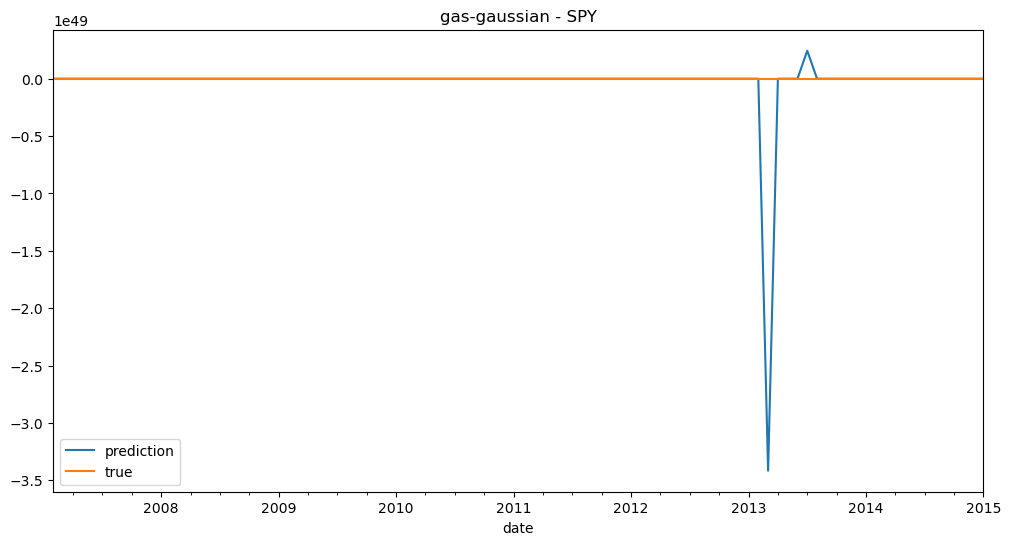

In [21]:
predictions_df[['prediction', 'true']].loc[:"2015-01-01"].plot(figsize=(12, 6), title="{} - {}".format(fs_method, target))